# 🧠 Mental Health Prediction from Social Media — CW2 Notebook
**Module:** Data Analytics – CMP020L012A  
**University of Roehampton**

---
### How to use this notebook
1. Go to **File → Save a copy in Drive** to save your own version
2. Run cells top to bottom using **Shift + Enter** or **Runtime → Run all**
3. Upload your Kaggle CSV when prompted in Section 2

---
### Notebook structure
| # | Section |
|---|---|
| 1 | Install & import packages |
| 2 | Load dataset |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Data preprocessing |
| 5 | Feature engineering |
| 6 | Model training & comparison |
| 7 | Results & evaluation metrics |
| 8 | SHAP explainability analysis |
| 9 | Conclusions & next steps |

---
## 1. Install & Import Packages
Colab already has pandas, numpy, matplotlib, seaborn, and scikit-learn.  
We only need to install the extras: **xgboost**, **shap**, **imbalanced-learn**, and **vaderSentiment**.

In [ ]:
# ── Install packages not pre-installed on Colab ───────────────────────────────
!pip install -q xgboost shap imbalanced-learn vaderSentiment
print("✅ Packages installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 1.7 MB/s eta 0:00:00
✅ Packages installed


In [ ]:
# ── Core imports ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, accuracy_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# XGBoost, SHAP, imbalanced-learn
from xgboost import XGBClassifier
import shap
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Sentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print(f"pandas  {pd.__version__}")
print(f"sklearn {__import__('sklearn').__version__}")
print(f"xgboost {__import__('xgboost').__version__}")
print(f"shap    {shap.__version__}")
print(f"imblearn {__import__('imblearn').__version__}")
print("✅ All imports successful")

pandas  2.2.2
sklearn 1.6.1
xgboost 3.2.0
shap    0.51.0
imblearn 0.14.1
✅ All imports successful


---
## 2. Load Dataset
Download the CSV from Kaggle:  
👉 [kaggle.com/datasets/souvikahamed357/social-media-and-mental-health](https://www.kaggle.com/datasets/souvikahamed357/social-media-and-mental-health)

Then upload it using the cell below.

In [ ]:
# ── Upload CSV from your computer ─────────────────────────────────────────────
from google.colab import files
uploaded = files.upload()   # Click 'Choose Files' and select the CSV

import io
filename = list(uploaded.keys())[0]
df_raw = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"✅ Loaded: {filename}")
print(f"   Shape : {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")

Saving smmh.csv to smmh (1).csv
✅ Loaded: smmh (1).csv
   Shape : 481 rows × 21 columns


In [ ]:
# ── Quick look at the data ────────────────────────────────────────────────────
print("── First 5 rows ──")
display(df_raw.head())

print("\n── Column names & dtypes ──")
display(df_raw.dtypes.to_frame('dtype'))

print("\n── Missing values ──")
missing = df_raw.isnull().sum()
display(missing[missing > 0].to_frame('missing_count'))

── First 5 rows ──


,Timestamp,1. What is your age?,2. Gender,3. Relationship Status,4. Occupation Status,5. What type of organizations are you affiliated with?,6. Do you use social media?,7. What social media platforms do you commonly use?,8. What is the average time you spend on social media every day?,9. How often do you find yourself using Social media without a specific purpose?,10. How often do you get distracted by Social media when you are busy doing something?,11. Do you feel restless if you haven't used Social media in a while?,"12. On a scale of 1 to 5, how easily distracted are you?","13. On a scale of 1 to 5, how much are you bothered by worries?",14. Do you find it difficult to concentrate on things?,"15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?","16. Following the previous question, how do you feel about these comparisons, generally speaking?",17. How often do you look to seek validation from features of social media?,18. How often do you feel depressed or down?,"19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?","20. On a scale of 1 to 5, how often do you face issues regarding sleep?"
0,4/18/2022 19:18:47,21.000,Male,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,3,2,5,2,5,2,3,2,5,4,5
1,4/18/2022 19:19:28,21.000,Female,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,3,2,4,5,4,5,1,1,5,4,5
2,4/18/2022 19:25:59,21.000,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,3,2,1,2,5,4,3,3,1,4,2,5
3,4/18/2022 19:29:43,21.000,Female,Single,University Student,University,Yes,"Facebook, Instagram",More than 5 hours,4,2,1,3,5,3,5,1,2,4,3,2
4,4/18/2022 19:33:31,21.000,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube",Between 2 and 3 hours,3,5,4,4,5,5,3,3,3,4,4,1



── Column names & dtypes ──


,dtype
Timestamp,object
1. What is your age?,float64
2. Gender,object
3. Relationship Status,object
4. Occupation Status,object
5. What type of organizations are you affiliated with?,object
6. Do you use social media?,object
7. What social media platforms do you commonly use?,object
8. What is the average time you spend on social media every day?,object
9. How often do you find yourself using Social media without a specific purpose?,int64



── Missing values ──


,missing_count
5. What type of organizations are you affiliated with?,30


---
## 3. Exploratory Data Analysis (EDA)
Before any modelling, we need to understand the data: distributions, class balance, and correlations.

In [ ]:
# ── Descriptive statistics ────────────────────────────────────────────────────
display(df_raw.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Timestamp,481,480,5/11/2022 22:54:32,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1. What is your age?,481.000,NaN,NaN,NaN,26.137,9.915,13.000,21.000,22.000,26.000,91.000
2. Gender,481,9,Female,263,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3. Relationship Status,481,4,Single,285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4. Occupation Status,481,4,University Student,292,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5. What type of organizations are you affiliated with?,451,18,University,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6. Do you use social media?,481,2,Yes,478,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7. What social media platforms do you commonly use?,481,125,"Facebook, Instagram, YouTube",35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8. What is the average time you spend on social media every day?,481,6,More than 5 hours,116,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9. How often do you find yourself using Social media without a specific purpose?,481.000,NaN,NaN,NaN,3.553,1.096,1.000,3.000,4.000,4.000,5.000


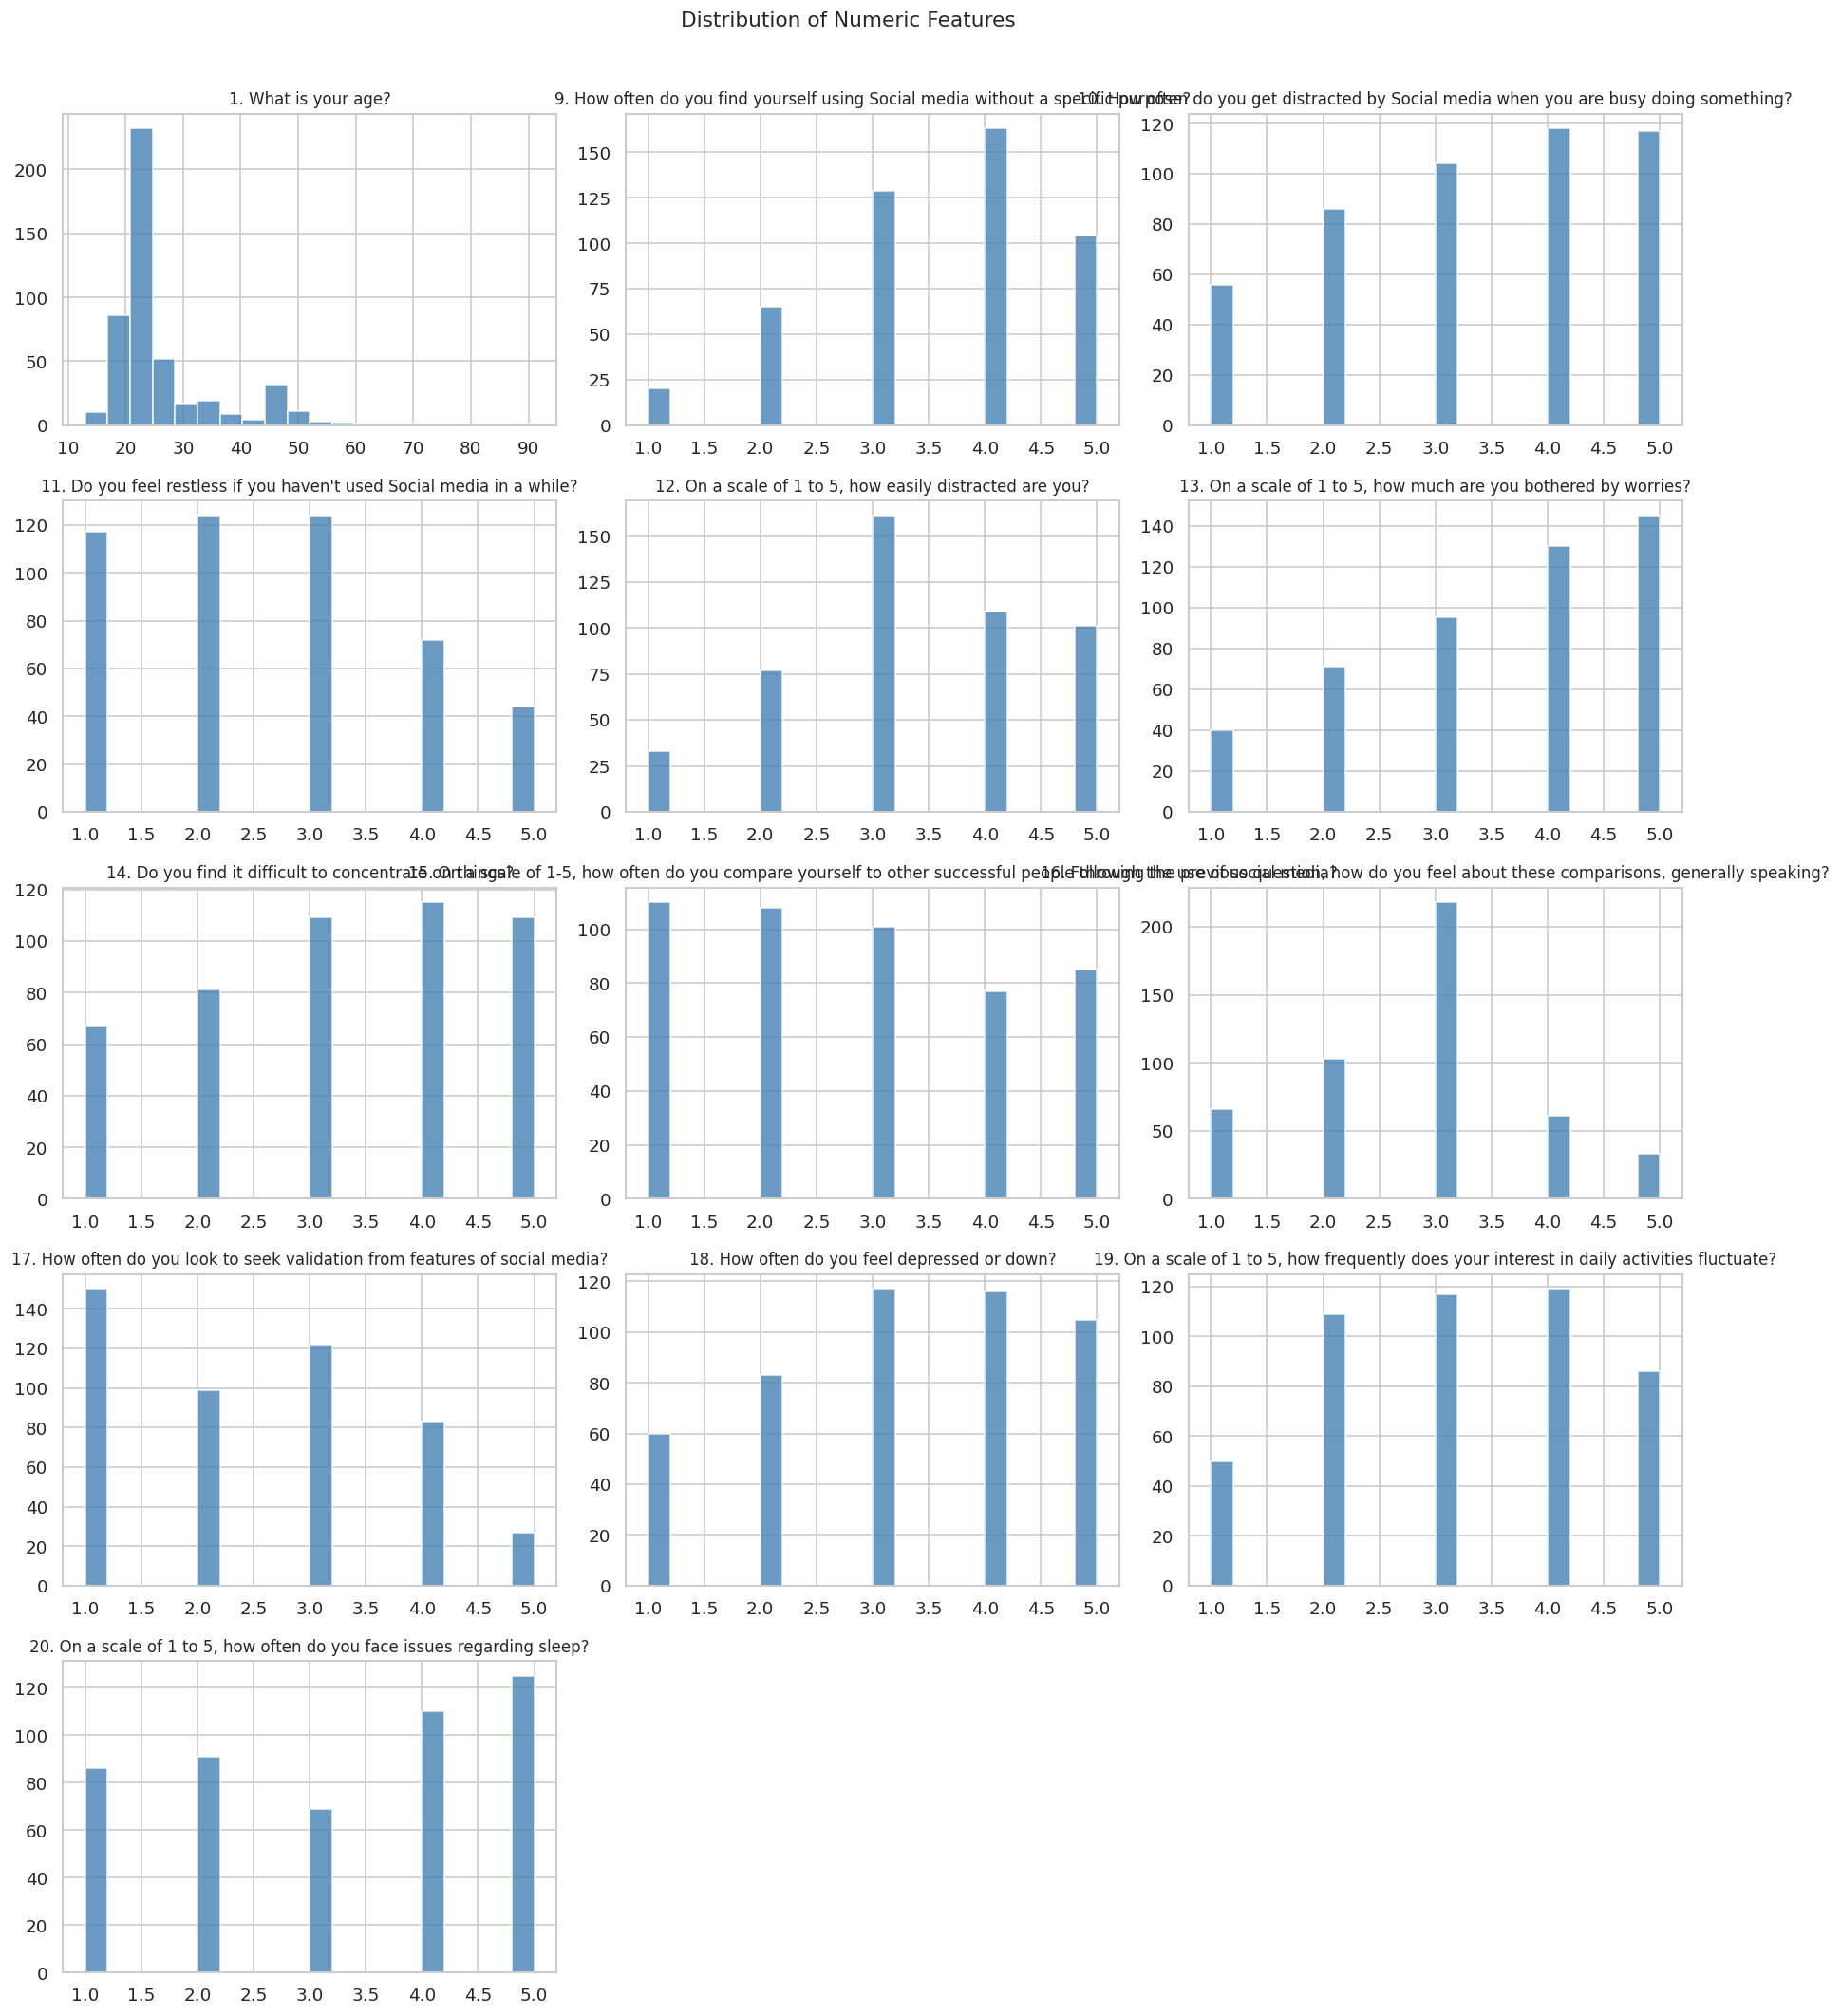

In [ ]:
# ── Target variable distribution ──────────────────────────────────────────────
# NOTE: Update 'your_target_column' to the actual column name after loading data
# Common PHQ-4 based columns will appear after you load the dataset

# Plot distributions of all numeric columns
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df_raw[col].dropna(), bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numeric Features', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

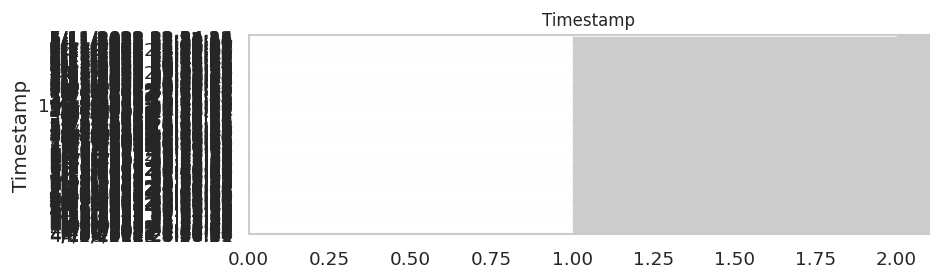

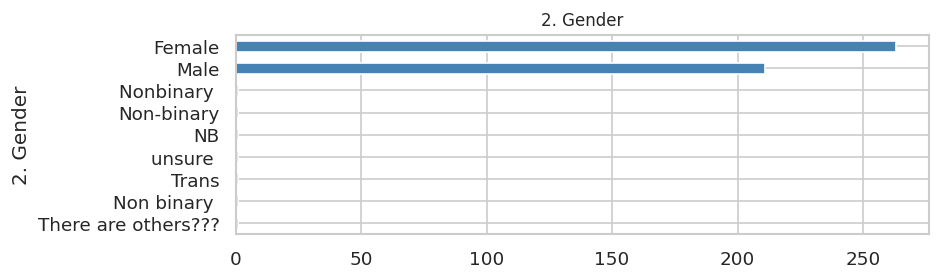

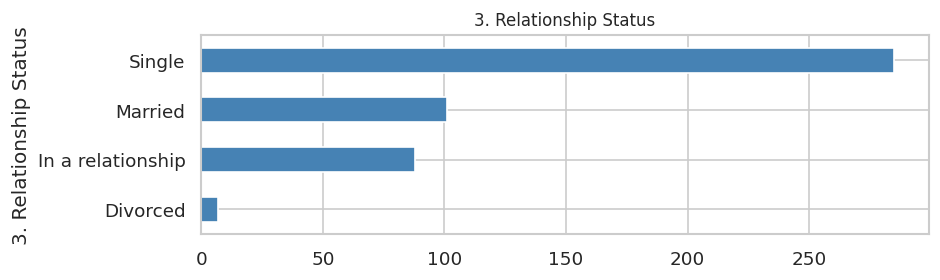

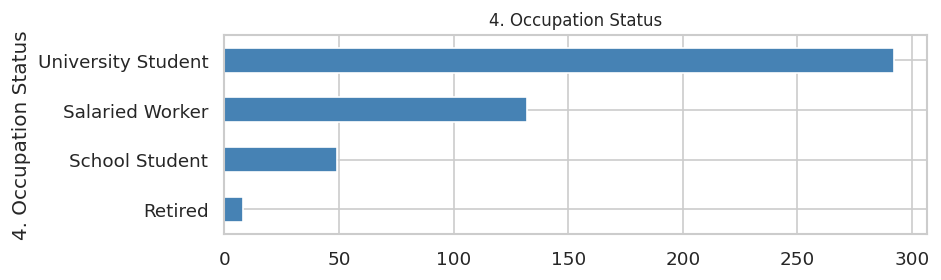

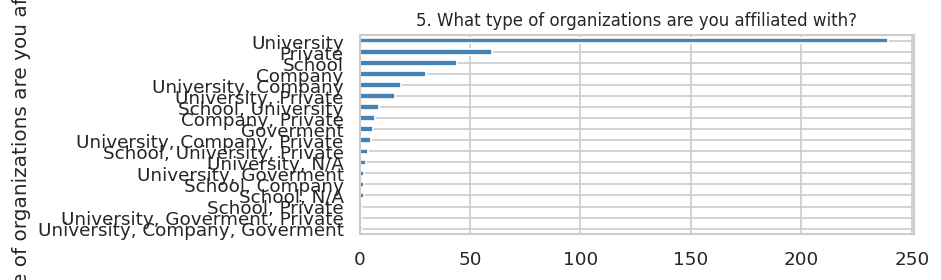

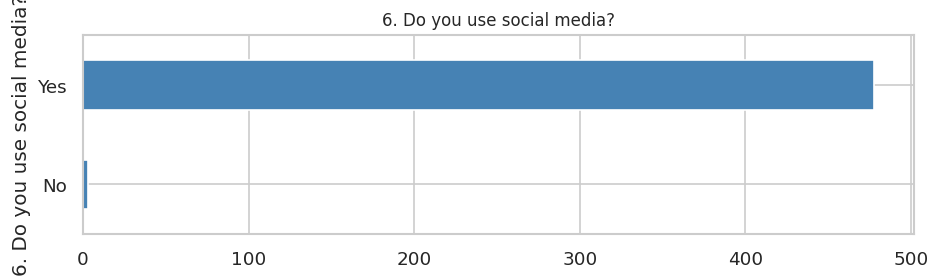

In [ ]:
# ── Categorical feature counts ────────────────────────────────────────────────
cat_cols = df_raw.select_dtypes(include=['object', 'category']).columns.tolist()

for col in cat_cols[:6]:   # show first 6 to keep output manageable
    fig, ax = plt.subplots(figsize=(8, 2.5))
    counts = df_raw[col].value_counts()
    counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=10)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

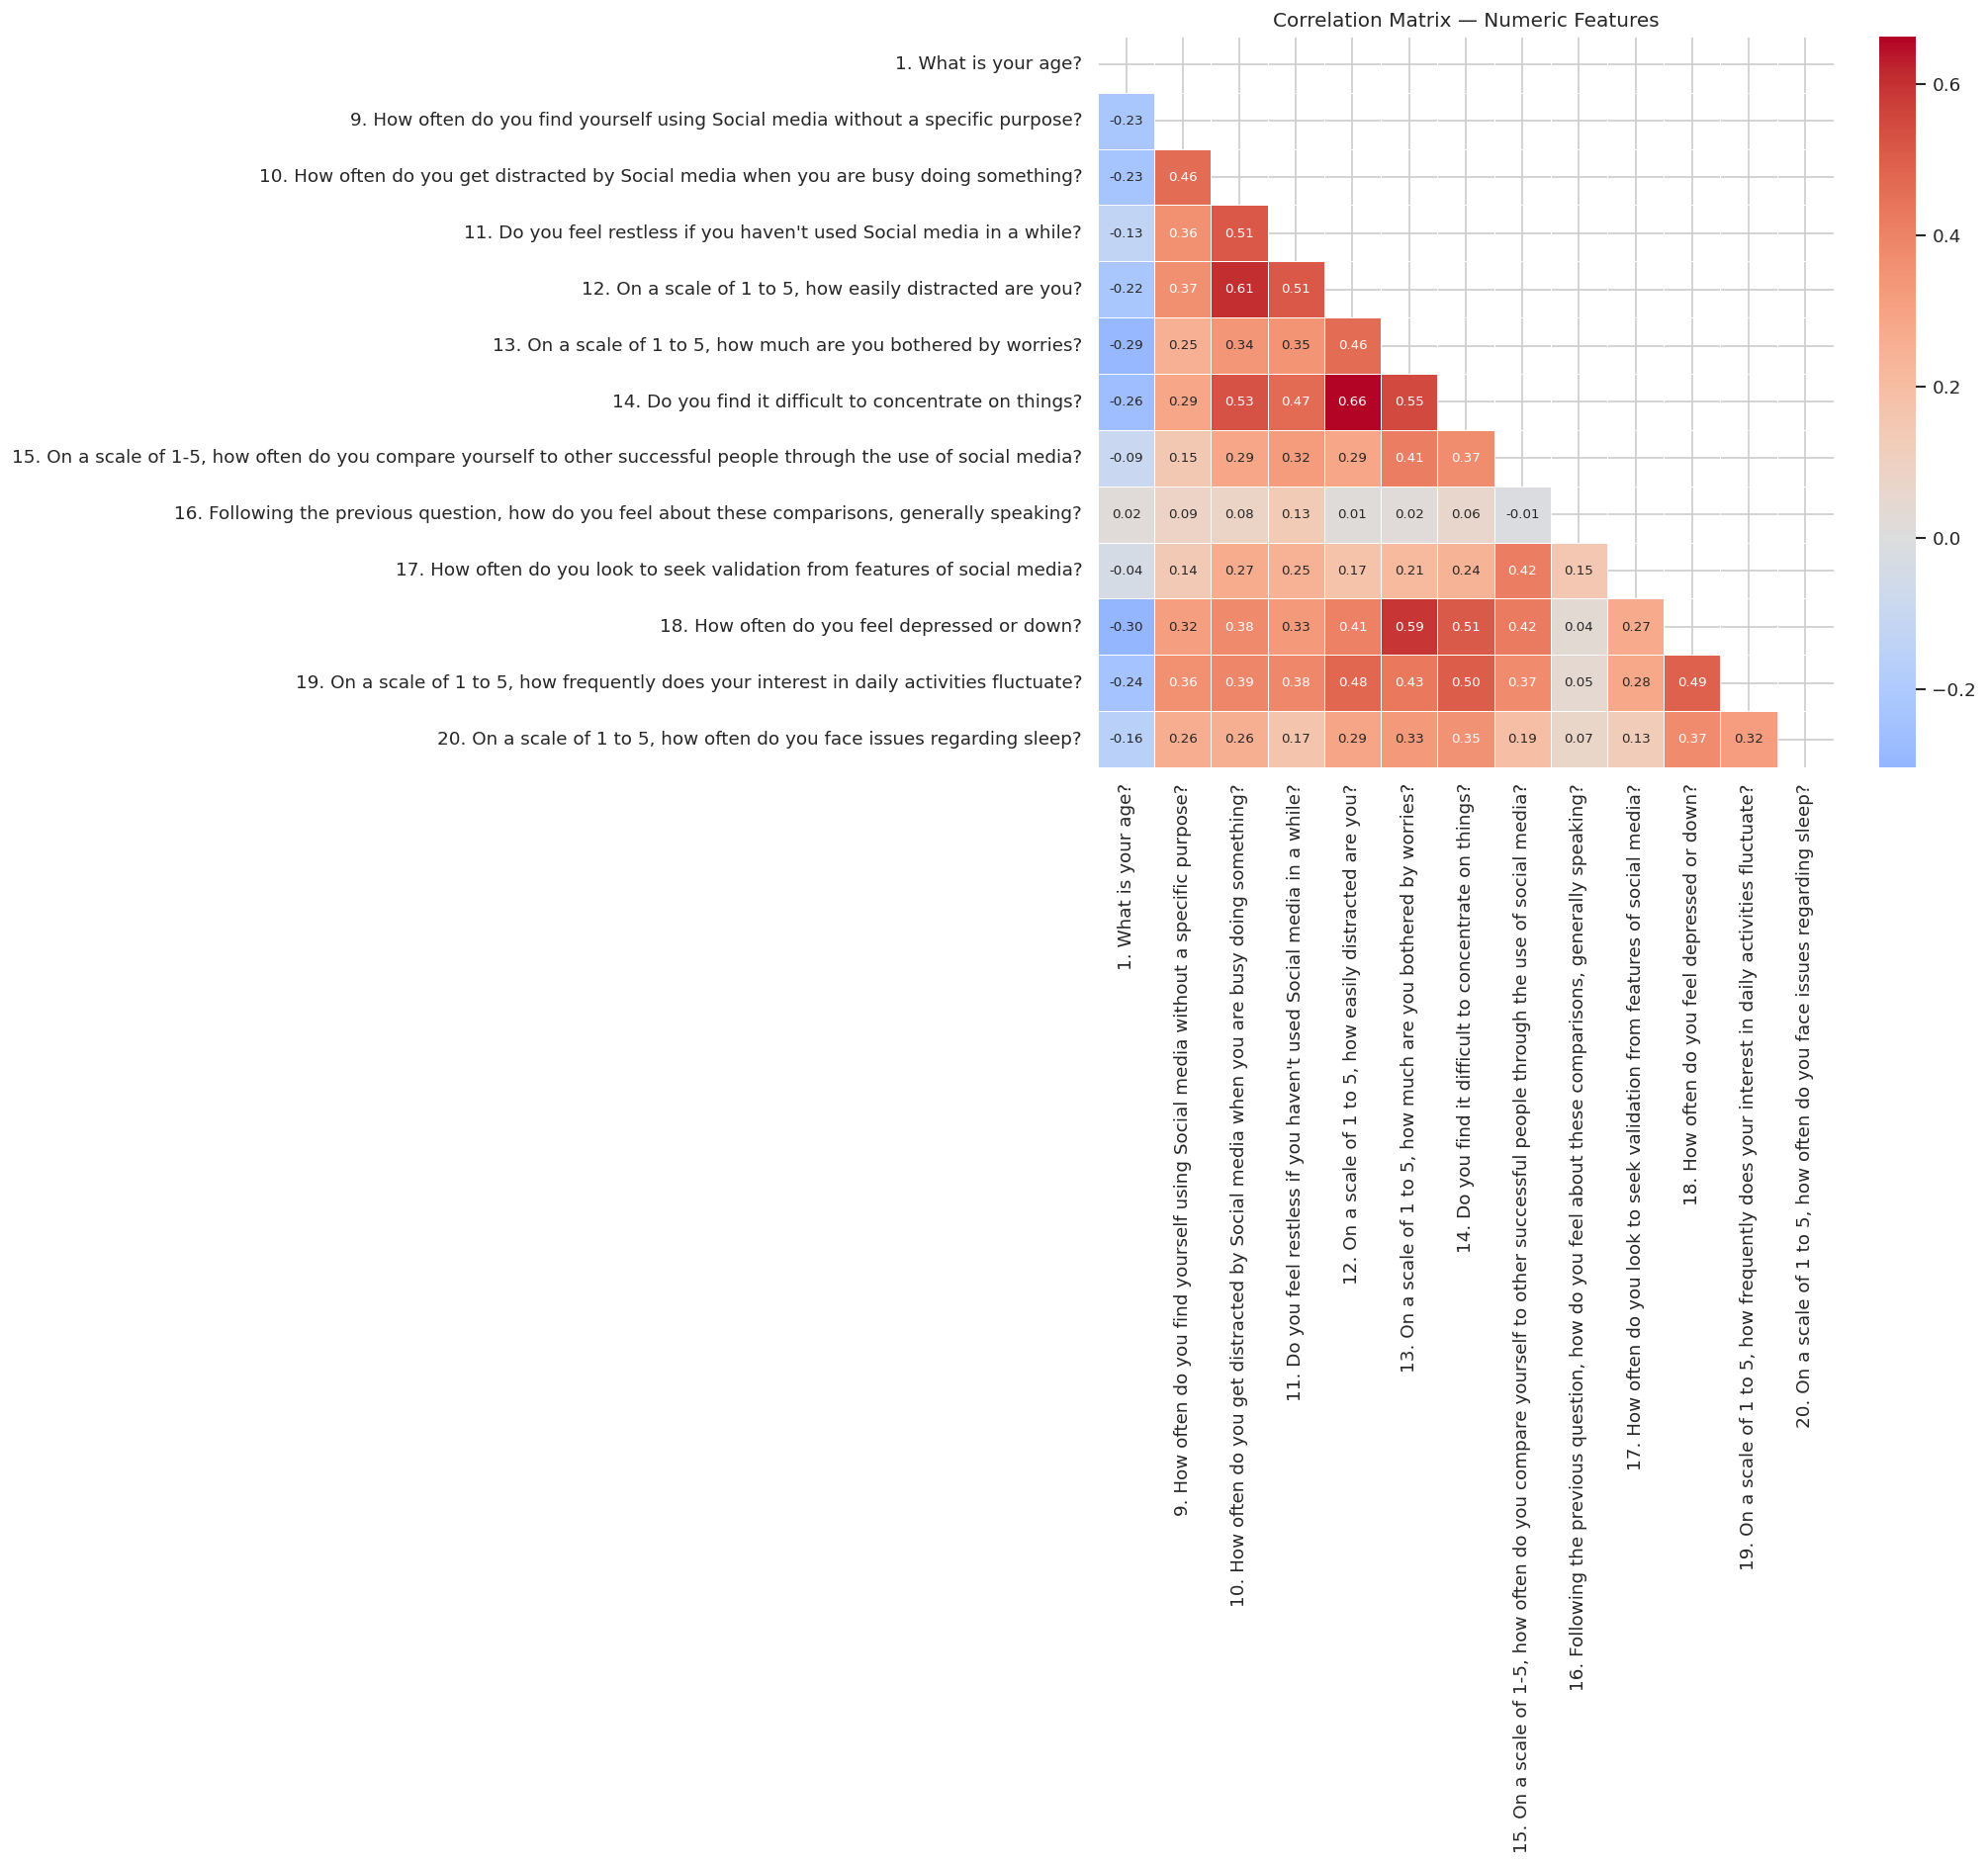

In [ ]:
# ── Correlation heatmap (numeric features only) ───────────────────────────────
corr = df_raw[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.4,
    ax=ax, annot_kws={'size': 8}
)
ax.set_title('Correlation Matrix — Numeric Features', fontsize=12)
plt.tight_layout()
plt.show()

---
## 4. Data Preprocessing
Handle missing values, encode categorical variables, and scale numeric features.

In [ ]:
# ── Copy raw data so we can always go back to it ──────────────────────────────
df = df_raw.copy()

# ── 1. Rename columns for easier handling (strip whitespace, lowercase) ───────
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace(r'[^a-z0-9_]', '', regex=True)
)
print("Cleaned column names:")
print(df.columns.tolist())

Cleaned column names:
['timestamp', '1_what_is_your_age', '2_gender', '3_relationship_status', '4_occupation_status', '5_what_type_of_organizations_are_you_affiliated_with', '6_do_you_use_social_media', '7_what_social_media_platforms_do_you_commonly_use', '8_what_is_the_average_time_you_spend_on_social_media_every_day', '9_how_often_do_you_find_yourself_using_social_media_without_a_specific_purpose', '10_how_often_do_you_get_distracted_by_social_media_when_you_are_busy_doing_something', '11_do_you_feel_restless_if_you_havent_used_social_media_in_a_while', '12_on_a_scale_of_1_to_5_how_easily_distracted_are_you', '13_on_a_scale_of_1_to_5_how_much_are_you_bothered_by_worries', '14_do_you_find_it_difficult_to_concentrate_on_things', '15_on_a_scale_of_15_how_often_do_you_compare_yourself_to_other_successful_people_through_the_use_of_social_media', '16_following_the_previous_question_how_do_you_feel_about_these_comparisons_generally_speaking', '17_how_often_do_you_look_to_seek_validation_fro

In [ ]:
# ── 2. Handle missing values ──────────────────────────────────────────────────
# Numeric columns: fill with median
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical columns: fill with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f"Missing values remaining: {df.isnull().sum().sum()}")
print("✅ Missing values handled")

Missing values remaining: 0
✅ Missing values handled


In [ ]:
# ── 3. Encode categorical features ───────────────────────────────────────────
le = LabelEncoder()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))

print(f"Encoded {len(cat_cols)} categorical columns")
print("✅ Encoding done")

Encoded 8 categorical columns
✅ Encoding done


In [ ]:
# ── 4. Define features (X) and target (y) ────────────────────────────────────
# ⚠️ UPDATE: Replace 'your_target_column' with the actual mental health
# outcome column from the dataset (e.g. a PHQ-4 score column).
# After running Section 2 you will see the real column names.

TARGET_COL = '18_how_often_do_you_feel_depressed_or_down'   # <-- update this after loading data

# Use encoded + numeric columns as features, drop original categoricals & target
drop_cols = cat_cols + [TARGET_COL]
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols]
y = df[TARGET_COL]

print(f"Features : {X.shape[1]} columns")
print(f"Samples  : {X.shape[0]} rows")
print(f"Target distribution:\n{y.value_counts()}")

Features : 20 columns
Samples  : 481 rows
Target distribution:
18_how_often_do_you_feel_depressed_or_down
3    117
4    116
5    105
2     83
1     60
Name: count, dtype: int64


---
## 5. Feature Engineering
Create the VADER sentiment score (for any free-text columns) and a class-imbalance summary.

In [ ]:
# ── VADER sentiment on any free-text column ───────────────────────────────────
# If the dataset has a text/comments column, replace 'text_column' below.
# If there is no text column, skip this cell.

TEXT_COL = None   # e.g. 'comments' — set to None to skip

if TEXT_COL and TEXT_COL in df_raw.columns:
    analyser = SentimentIntensityAnalyzer()

    df['vader_pos']  = df_raw[TEXT_COL].fillna('').apply(lambda t: analyser.polarity_scores(t)['pos'])
    df['vader_neg']  = df_raw[TEXT_COL].fillna('').apply(lambda t: analyser.polarity_scores(t)['neg'])
    df['vader_neu']  = df_raw[TEXT_COL].fillna('').apply(lambda t: analyser.polarity_scores(t)['neu'])
    df['vader_compound'] = df_raw[TEXT_COL].fillna('').apply(lambda t: analyser.polarity_scores(t)['compound'])

    print("✅ VADER sentiment features added")
    display(df[['vader_pos','vader_neg','vader_neu','vader_compound']].describe())
else:
    print("ℹ️  No text column specified — VADER step skipped")

ℹ️  No text column specified — VADER step skipped


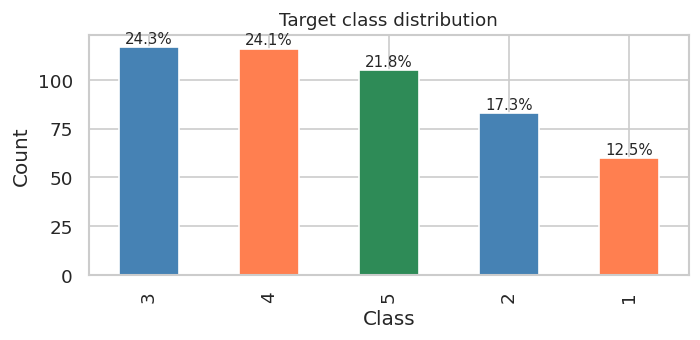

Imbalance ratio (majority:minority): 1.9:1
⚠️  Class imbalance detected — SMOTE will be applied in Section 6


In [ ]:
# ── Class imbalance check ─────────────────────────────────────────────────────
class_counts = y.value_counts()
class_pct    = y.value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 3))
class_counts.plot(kind='bar', ax=ax, color=['steelblue','coral','seagreen'][:len(class_counts)], edgecolor='white')
ax.set_title('Target class distribution', fontsize=11)
ax.set_xlabel('Class')
ax.set_ylabel('Count')
for i, (cnt, pct) in enumerate(zip(class_counts, class_pct)):
    ax.text(i, cnt + 2, f'{pct:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Imbalance ratio (majority:minority): {imbalance_ratio:.1f}:1")
if imbalance_ratio > 1.5:
    print("⚠️  Class imbalance detected — SMOTE will be applied in Section 6")

---
## 6. Model Training & Comparison
We train four classifiers inside a SMOTE pipeline with stratified 10-fold cross-validation.

In [ ]:
# ── Define the four models ────────────────────────────────────────────────────
RANDOM_STATE = 42

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=5,
        use_label_encoder=False, eval_metric='logloss',
        random_state=RANDOM_STATE
    ),
    'MLP (Neural Network)': MLPClassifier(
        hidden_layer_sizes=(128, 64), max_iter=500,
        random_state=RANDOM_STATE
    ),
}

print("Models defined:")
for name in models:
    print(f"  • {name}")

Models defined:
  • Logistic Regression
  • Random Forest
  • XGBoost
  • MLP (Neural Network)


In [ ]:
# ── Stratified 10-fold cross-validation with SMOTE ─────────────
from sklearn.preprocessing import label_binarize

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
scaler = StandardScaler()

scoring = ['accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted']
results = {}

# Adjust target labels for models that expect 0-indexed classes (like XGBoost)
y_adjusted = y - 1 # Subtract 1 from all target labels

for name, model in models.items():
    print(f"Training: {name} ...", end=' ')

    pipe = ImbPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  scaler),
        ('smote',   SMOTE(random_state=RANDOM_STATE)),
        ('clf',     model)
    ])

    # Use y_adjusted instead of y for cross-validation
    cv_scores = cross_validate(pipe, X, y_adjusted, cv=cv, scoring=scoring, return_train_score=False)
    results[name] = {
        'Accuracy':  cv_scores['test_accuracy'].mean(),
        'F1':        cv_scores['test_f1_weighted'].mean(),
        'Precision': cv_scores['test_precision_weighted'].mean(),
        'Recall':    cv_scores['test_recall_weighted'].mean(),
        'Accuracy±': cv_scores['test_accuracy'].std(),
        'F1±':       cv_scores['test_f1_weighted'].std(),
    }
    print(f"✅  Accuracy={results[name]['Accuracy']:.3f}")

print("\n✅ All models trained")

Training: Logistic Regression ... ✅  Accuracy=0.364
Training: Random Forest ... ✅  Accuracy=0.410
Training: XGBoost ... ✅  Accuracy=0.366
Training: MLP (Neural Network) ... ✅  Accuracy=0.366

✅ All models trained


---
## 7. Results & Evaluation Metrics

In [ ]:
# ── Summary table ─────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results).T[['Accuracy','F1','Precision','Recall','Accuracy±','F1±']]
results_df = results_df.sort_values('F1', ascending=False)

print("10-Fold Cross-Validation Results (mean ± std):")
display(
    results_df.style
    .background_gradient(subset=['Accuracy','F1','Precision','Recall'], cmap='YlGn')
    .format('{:.4f}')
    .set_caption('Model Comparison — Stratified 10-Fold CV with SMOTE')
)

10-Fold Cross-Validation Results (mean ± std):


,Accuracy,F1,Precision,Recall,Accuracy±,F1±
Random Forest,0.4097,0.4032,0.4144,0.4097,0.0641,0.0617
MLP (Neural Network),0.3658,0.3610,0.3769,0.3658,0.0529,0.0533
XGBoost,0.3659,0.3571,0.3697,0.3659,0.0568,0.0539
Logistic Regression,0.3638,0.3466,0.3503,0.3638,0.0428,0.0369


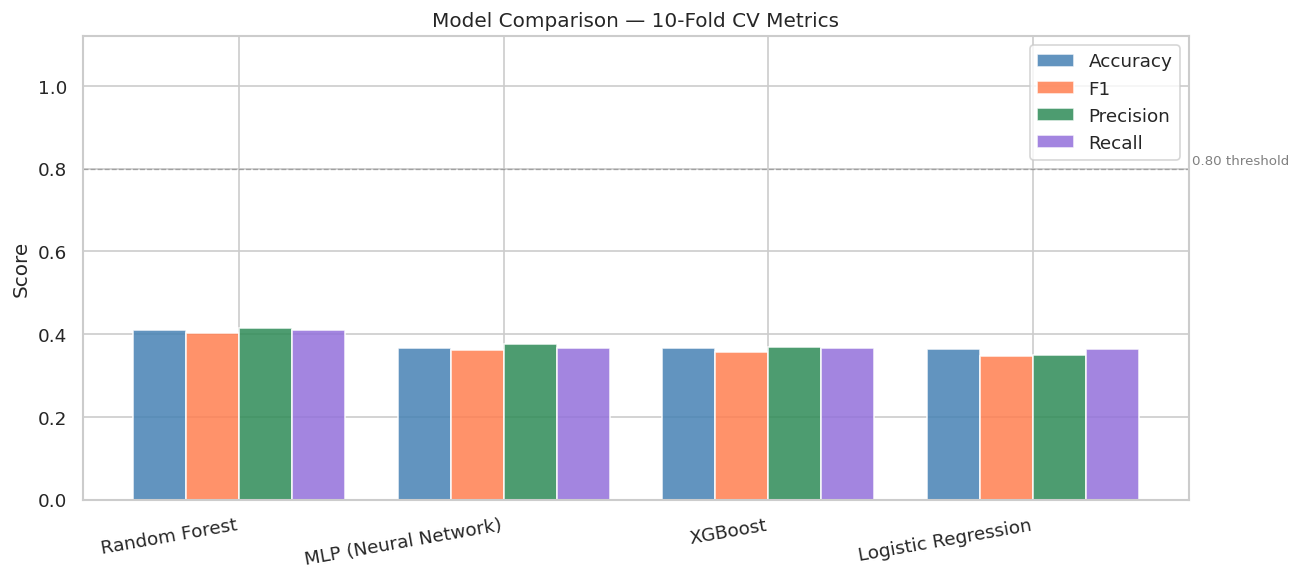

In [ ]:
# ── Bar chart comparison ──────────────────────────────────────────────────────
metrics_to_plot = ['Accuracy', 'F1', 'Precision', 'Recall']
x = np.arange(len(results_df))
width = 0.2
colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    bars = ax.bar(x + i * width, results_df[metric], width, label=metric,
                  color=color, edgecolor='white', alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df.index, rotation=10, ha='right')
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — 10-Fold CV Metrics', fontsize=12)
ax.legend(loc='upper right')
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.text(len(results_df) - 0.1, 0.81, '0.80 threshold', color='gray', fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# ── Detailed report for best model (XGBoost) ───────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_adjusted, test_size=0.2, stratify=y_adjusted, random_state=RANDOM_STATE
)

best_pipe = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('smote',   SMOTE(random_state=RANDOM_STATE)),
    ('clf',     XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=5,
        use_label_encoder=False, eval_metric='logloss',
        random_state=RANDOM_STATE
    ))
])

best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

print("Classification Report — XGBoost (held-out test set)")
print("=" * 55)
print(classification_report(y_test, y_pred))

Classification Report — XGBoost (held-out test set)
              precision    recall  f1-score   support

           0       0.50      0.42      0.45        12
           1       0.33      0.47      0.39        17
           2       0.29      0.21      0.24        24
           3       0.38      0.35      0.36        23
           4       0.36      0.43      0.39        21

    accuracy                           0.36        97
   macro avg       0.37      0.37      0.37        97
weighted avg       0.36      0.36      0.36        97



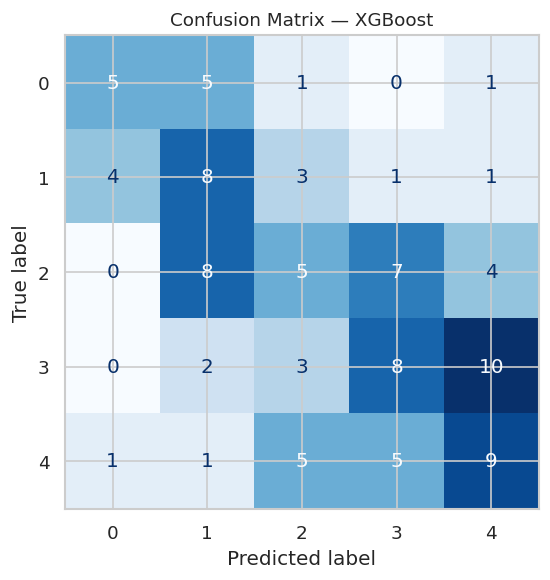

In [ ]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=ax, colorbar=False,
    cmap='Blues'
)
ax.set_title('Confusion Matrix — XGBoost', fontsize=11)
plt.tight_layout()
plt.show()

---
## 8. SHAP Explainability Analysis
SHAP (SHapley Additive exPlanations) reveals which features drive predictions — required for the XAI section of CW2.

In [ ]:
# ── Fit XGBoost directly on scaled data for SHAP ──────────────────────────────
# (SHAP needs the final model and transformed features separately)
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(strategy='median')
scaler_shap = StandardScaler()
smote_shap  = SMOTE(random_state=RANDOM_STATE)

X_imp   = imputer.fit_transform(X_train)
X_sc    = scaler_shap.fit_transform(X_imp)
X_res, y_res = smote_shap.fit_resample(X_sc, y_train)

xgb_model = XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=5,
    use_label_encoder=False, eval_metric='logloss',
    random_state=RANDOM_STATE
)
xgb_model.fit(X_res, y_res)

# Transform test set the same way
X_test_imp = imputer.transform(X_test)
X_test_sc  = scaler_shap.transform(X_test_imp)

print("✅ XGBoost fitted for SHAP analysis")

✅ XGBoost fitted for SHAP analysis


In [ ]:
# ── Compute SHAP values ───────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_sc)

feature_names = X.columns.tolist()

print("✅ SHAP values computed")
print(f"   Shape: {np.array(shap_values).shape}")

✅ SHAP values computed
   Shape: (97, 20, 5)


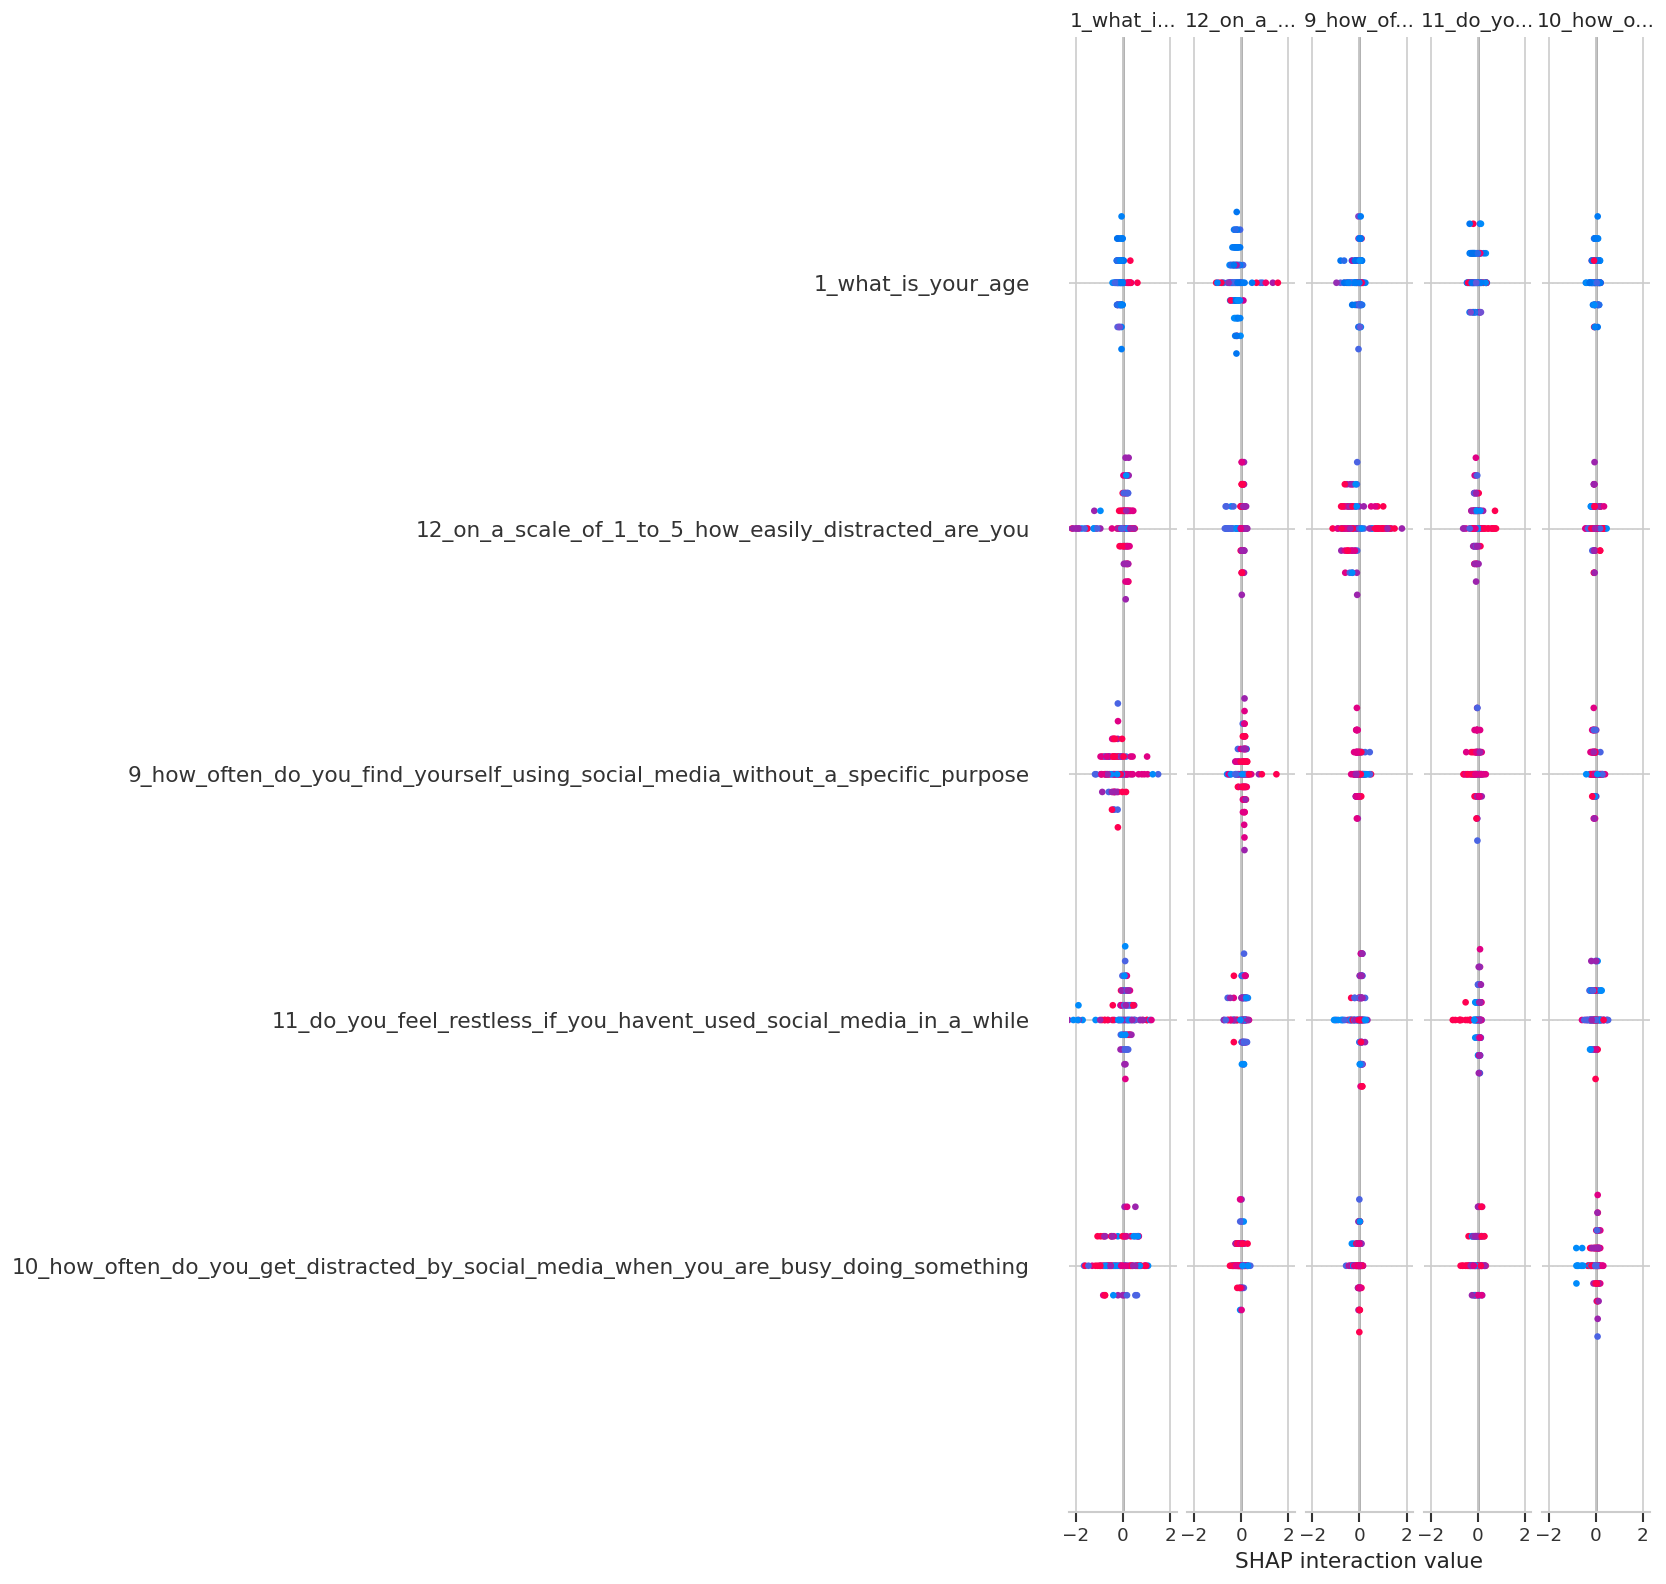

In [ ]:
# ── SHAP summary plot (beeswarm) ──────────────────────────────────────────────
shap.summary_plot(
    shap_values, X_test_sc,
    feature_names=feature_names,
    plot_type='dot',
    max_display=15,
    show=True
)

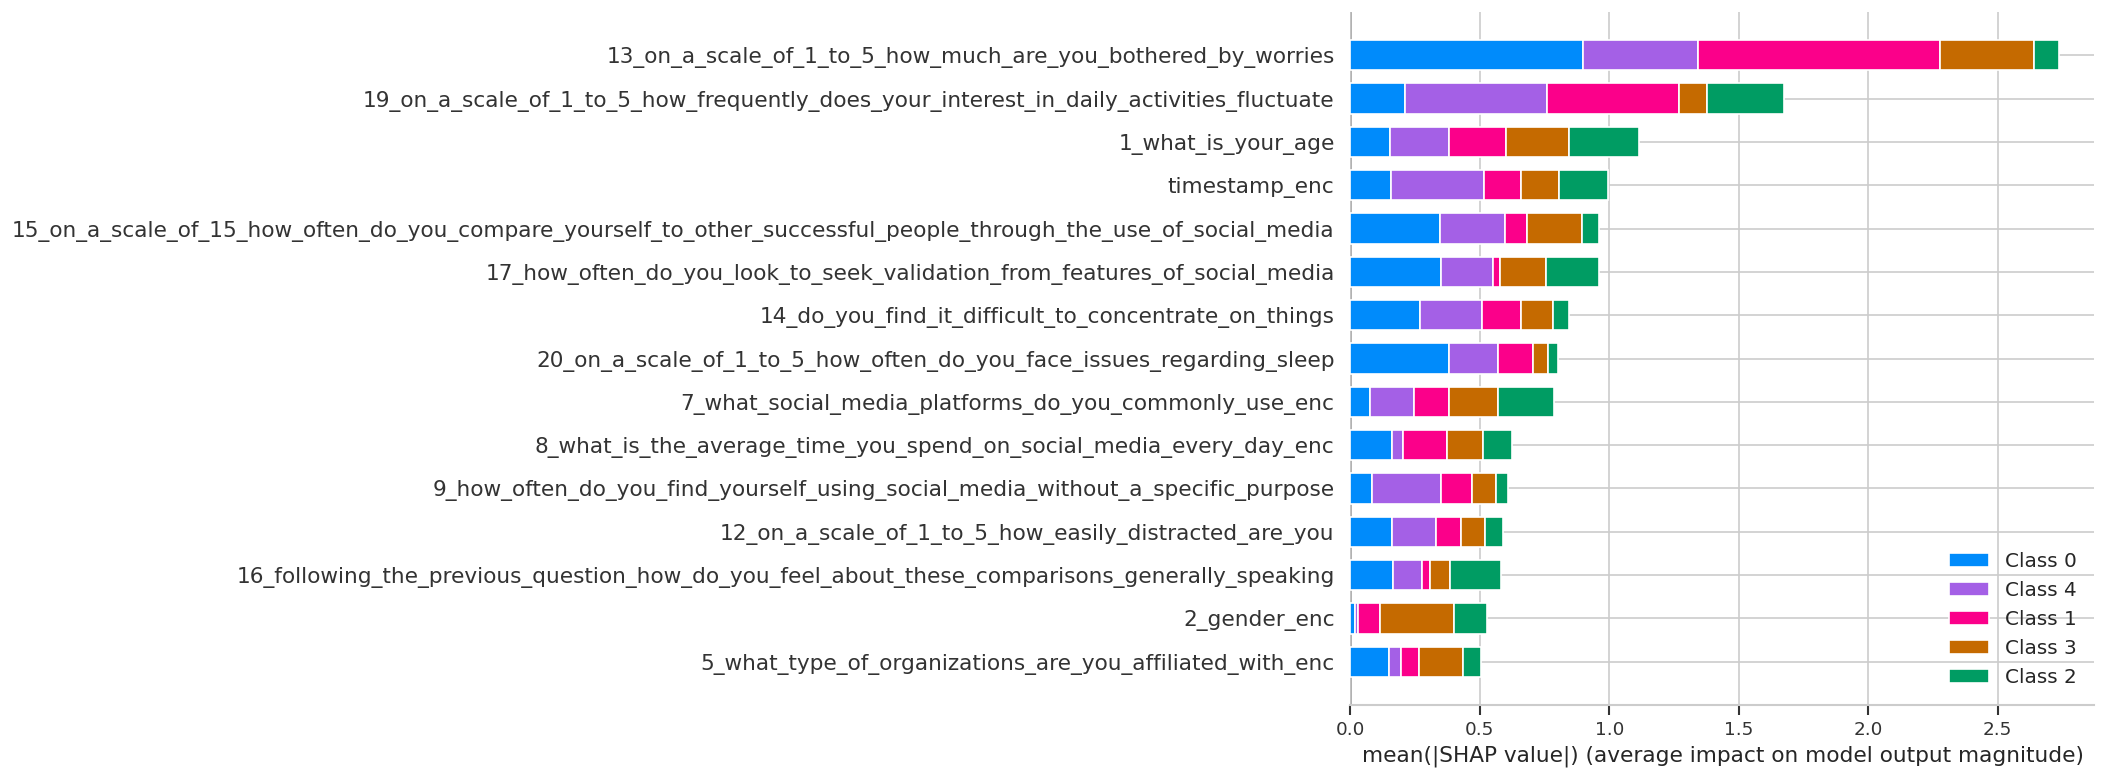

In [ ]:
# ── SHAP bar chart — mean absolute importance ─────────────────────────────────
shap.summary_plot(
    shap_values, X_test_sc,
    feature_names=feature_names,
    plot_type='bar',
    max_display=15,
    show=True
)

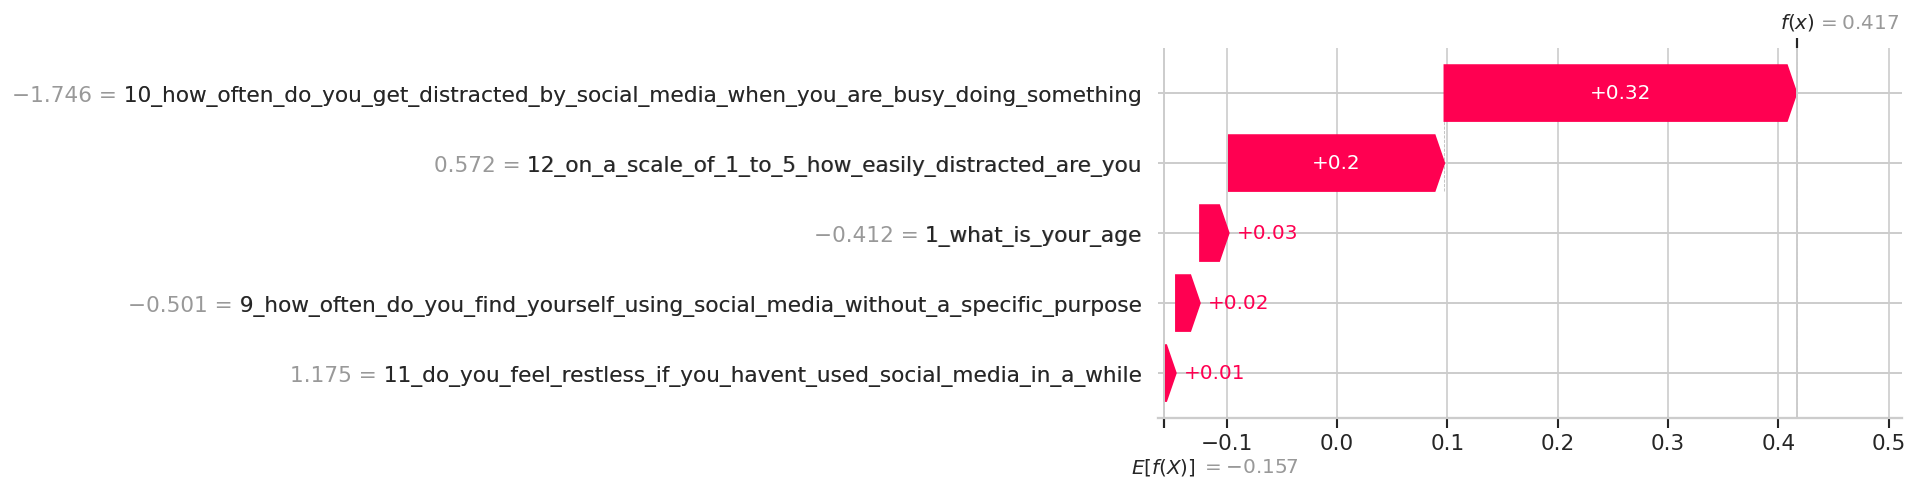

In [ ]:
# ── SHAP waterfall plot — single prediction explanation ───────────────────────
# Shows why the model made the prediction it did for the first test instance
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0, 0] if isinstance(shap_values, list) else shap_values[0, 0],
        base_values=explainer.expected_value[0] if isinstance(explainer.expected_value, list) else explainer.expected_value[0],
        data=X_test_sc[0],
        feature_names=feature_names
    )
)

---
## 9. Conclusions & Next Steps

Use this section to write up your findings for the CW2 report.

**Template — fill in after running the notebook:**

```
Best model          : [XGBoost / Random Forest / ...]
Best F1 score       : [0.xx]
Best AUC-ROC        : [0.xx]
Top 3 SHAP features : [feature 1], [feature 2], [feature 3]
Class imbalance fix : SMOTE improved recall by [x]%
Main limitation     : [self-reported labels / small N / ...]
```

**Key points to discuss in your report:**
- Which features had the highest SHAP values, and does this match the clinical psychology literature (De Choudhury et al., 2013; Keles et al., 2020)?
- How much did SMOTE improve minority-class recall vs the baseline?
- Where does XGBoost outperform Logistic Regression, and why (non-linear interactions)?
- What are the ethical implications of deploying a model like this?

In [ ]:
results_df.to_csv('model_comparison_results.csv')
from google.colab import files
files.download('model_comparison_results.csv')
print("✅ Results saved and downloaded")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Results saved and downloaded
